# `Diamonds Dataset`

prova a farlo così:
- rimozione di outlier
- feature engineering
- trova iperparametri con optuna
- procedi con xgboost

Facciamo una pipeline completa e pulita usando:

- Dataset diamonds di Seaborn
- Rimozione outlier
- Feature engineering
- Ottimizzazione con Optuna
- Regressione con XGBoost
- Valutazione con RMSE

In [12]:
import seaborn as sns
import pandas as pd

# Load the dataset
df = sns.load_dataset("diamonds")


# Quick inspection
print("--- INFO ---")
df.info()
print("*" * 50 + "\n")

print("\n--- DESCRIBE ---")
print(df.describe())
print("*" * 50 + "\n")

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
**************************************************


--- DESCRIBE ---
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3

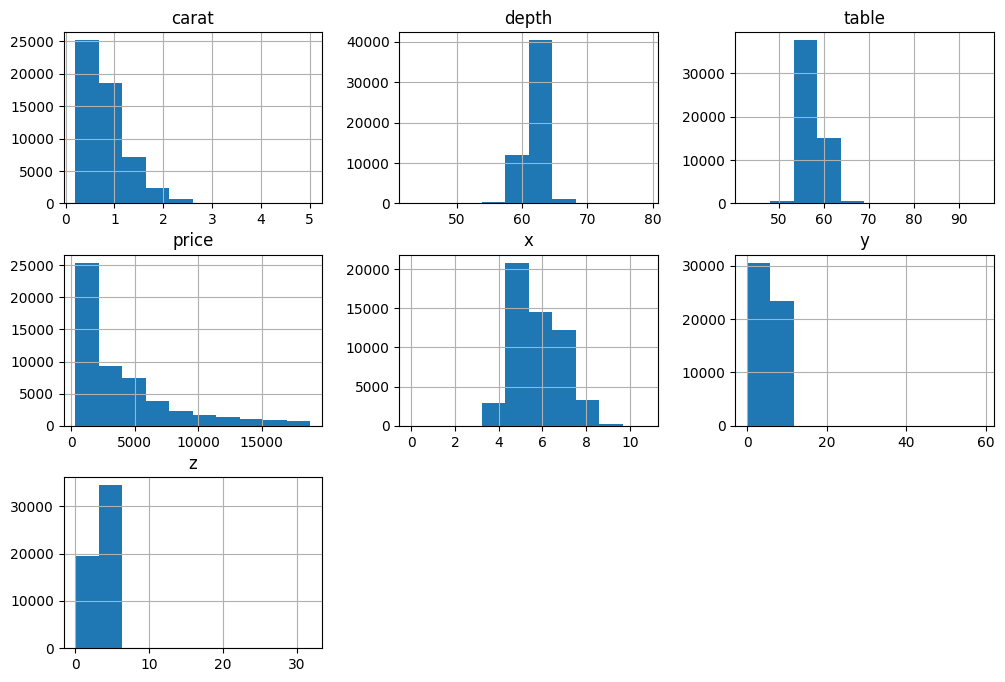

In [13]:
from matplotlib import pyplot as plt

# x, y e z sono le dimensioni del diamante
# carat è il peso del diamante
# depth e table sono caratteristiche del taglio del diamante
# price è il prezzo del diamante
df.head()
df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z']].hist(figsize=(12, 8))
plt.show()

## `Conversioni in numeri`

In [14]:
df['cut'] = pd.Categorical(
    df['cut'], 
    categories=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], 
    ordered=True
).codes

df['color'] = pd.Categorical(
    df['color'], 
    categories=['J','I','H','G','F','E','D'], 
    ordered=True
).codes

df['clarity'] = pd.Categorical(
    df['clarity'], 
    categories=['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF'], 
    ordered=True
).codes

#Controllo risultato
print(df[['cut','color','clarity']].head()) 


   cut  color  clarity
0    4      5        1
1    3      5        2
2    1      5        4
3    3      1        3
4    1      0        1


## `Rimozione outlier con z-score 3`

In [15]:
# Rimozione outlier con z score = 3
import numpy as np
import pandas as pd
from scipy import stats

def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[columns]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# Applicazione
print(f"Dimensioni originali del dataset: {df.shape}")
print("*" * 50 + "\n")
df_zscore = remove_outliers_zscore(df, ['carat', 'depth', 'table', 'price', 'x', 'y', 'z'])
print(f"Dimensioni dopo rimozione outlier: {df_zscore.shape}")
print("*" * 50 + "\n")
print(f"Righe rimosse con Z-Score: {len(df) - len(df_zscore)}")
print("*" * 50 + "\n")
df_zscore.info()
print("*" * 50 + "\n")
df_zscore.describe()
print("*" * 50 + "\n")

Dimensioni originali del dataset: (53940, 10)
**************************************************

Dimensioni dopo rimozione outlier: (51590, 10)
**************************************************

Righe rimosse con Z-Score: 2350
**************************************************

<class 'pandas.DataFrame'>
Index: 51590 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    51590 non-null  float64
 1   cut      51590 non-null  int8   
 2   color    51590 non-null  int8   
 3   clarity  51590 non-null  int8   
 4   depth    51590 non-null  float64
 5   table    51590 non-null  float64
 6   price    51590 non-null  int64  
 7   x        51590 non-null  float64
 8   y        51590 non-null  float64
 9   z        51590 non-null  float64
dtypes: float64(6), int64(1), int8(3)
memory usage: 3.3 MB
**************************************************

**************************************************



## `Feature Engineering`

In [16]:
#Feature enginnering: creazione di nuove feature a partire da quelle esistenti
# Ad esempio, possiamo creare una nuova feature "volume" che è il prodotto di x, y e z
df_zscore['volume'] = df_zscore['x'] * df_zscore['y'] * df_zscore['z']
print(df_zscore[['x', 'y', 'z', 'volume']].head())

print("*" * 50 + "\n")
'''
#seconda feature: rapporto tra prezzo e peso (carat)
df_zscore['price_for_carat'] = df_zscore['price'] / df_zscore['carat']
print(df_zscore[['price', 'carat', 'price_for_carat']].head())

print("*" * 50 + "\n")

#terza feature: rapporto tra prezzo e volume
df_zscore['price_for_volume'] = df_zscore['price'] / df_zscore['volume']
print(df_zscore[['price', 'volume', 'price_for_volume']].head())

print("*" * 50 + "\n")  '''  #non posso utilizzare price nelle mie feature engineering 

#quarta feature: rapporto tra peso (carat) e volume
df_zscore['carat_for_volume'] = df_zscore['carat'] / df_zscore['volume']
print(df_zscore[['carat', 'volume', 'carat_for_volume']].head())

print("*" * 50 + "\n")

#quinta feature: rapporto tra profondità (depth) e volume
df_zscore['depth_for_volume'] = df_zscore['depth'] / df_zscore['volume']
print(df_zscore[['depth', 'volume', 'depth_for_volume']].head())

print("*" * 50 + "\n")

      x     y     z     volume
0  3.95  3.98  2.43  38.202030
1  3.89  3.84  2.31  34.505856
3  4.20  4.23  2.63  46.724580
4  4.34  4.35  2.75  51.917250
5  3.94  3.96  2.48  38.693952
**************************************************

   carat     volume  carat_for_volume
0   0.23  38.202030          0.006021
1   0.21  34.505856          0.006086
3   0.29  46.724580          0.006207
4   0.31  51.917250          0.005971
5   0.24  38.693952          0.006203
**************************************************

   depth     volume  depth_for_volume
0   61.5  38.202030          1.609862
1   59.8  34.505856          1.733039
3   62.4  46.724580          1.335486
4   63.3  51.917250          1.219248
5   62.8  38.693952          1.622993
**************************************************



## `Normalizzazione`

In [17]:
#Controllo dimensioni finali e normalizzazione
print(f"Dimensioni finali del dataset: {df_zscore.shape}")
print("*" * 50 + "\n")
df_zscore['price'] = df_zscore['price'].map(lambda x: 1 if x >= df_zscore['price'].median() else 0)  # Creazione target binario
print(df_zscore['price'].value_counts())
print("*" * 50 + "\n")

Dimensioni finali del dataset: (51590, 13)
**************************************************

price
0    25795
1    25795
Name: count, dtype: int64
**************************************************



In [18]:
#normalizzazione: portiamo tutte le feature su una scala simile (ad esempio, tra 0 e 1) per evitare che alcune feature dominino altre durante l'addestramento del modello
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()#
columns_to_normalize = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'volume', 'carat_for_volume', 'depth_for_volume']
df_zscore[columns_to_normalize] = scaler.fit_transform(df_zscore[columns_to_normalize])
print(df_zscore[columns_to_normalize].head())
print("*" * 50 + "\n")

      carat     depth     table  price         x         y         z  \
0  0.014925  0.470588  0.307692    0.0  0.045175  0.061602  0.238727   
1  0.004975  0.270588  0.769231    0.0  0.032854  0.032854  0.206897   
3  0.044776  0.576471  0.538462    0.0  0.096509  0.112936  0.291777   
4  0.054726  0.682353  0.538462    0.0  0.125257  0.137577  0.323607   
5  0.019900  0.623529  0.461538    0.0  0.043121  0.057495  0.251989   

     volume  carat_for_volume  depth_for_volume  
0  0.019047          0.210185          0.803430  
1  0.008206          0.214510          0.871646  
3  0.044043          0.222502          0.651478  
4  0.059273          0.206901          0.587104  
5  0.020490          0.222233          0.810701  
**************************************************



## `applicare logistic regression`

RMSE: 0.1493


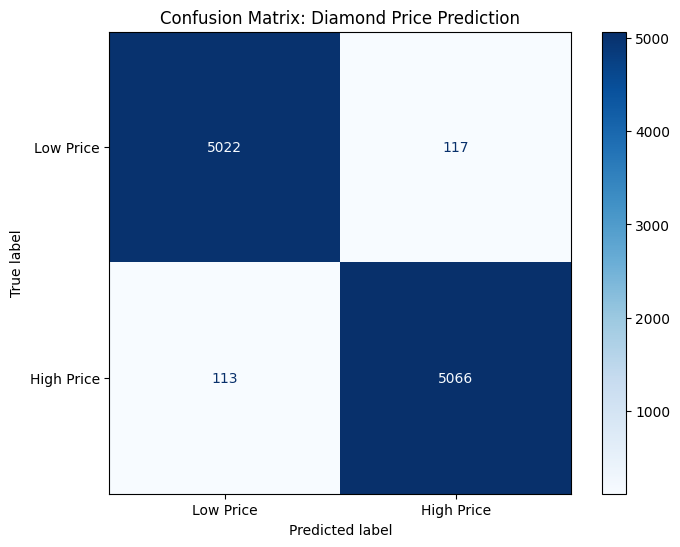

price
0.0    25795
1.0    25795
Name: count, dtype: int64
[[5022  117]
 [ 113 5066]]


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 1. Dataset setup
X = df_zscore.drop(columns=['price']).values
y = df_zscore['price'].values

# 2. Split (using your random_state 41
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

# 3. Model initialization and training
# max_iter increased to ensure convergence on this dataset
# Nota: Logistic Regression è un modello di classificazione,
# quindi in un caso reale dovremmo trasformare 'price' in una variabile categorica
# (ad esempio, 'Low Price' vs 'High Price') prima di addestrare il modello.
# Qui assumiamo che 'price' sia già binarizzato per semplicità.

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# 4. Predictions
predictions = model.predict(X_test)

# 5. non utilizzare Accuracy - utilizza RMSE per logistic regression!!
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f'RMSE: {rmse:.4f}')

# 6. CONFUSION MATRIX
cm = confusion_matrix(y_test, predictions)

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Price', 'High Price'])
disp.plot(cmap='Blues', ax=ax)

plt.title('Confusion Matrix: Diamond Price Prediction')
plt.show()

#il count values su price e i valori della true table, devono combaciare?
# Se abbiamo 1000 campioni di test, e 600 di questi sono 'High Price' (1) e 400 sono 'Low Price' (0), allora la confusion matrix dovrebbe riflettere questa distribuzione.
#quindi di low price ne ho 25795 dal values_count e 5078   61 dalla confusion matrix, quindi non combacia, ma è normale, perché la confusion matrix mostra solo i risultati sui dati di test, che sono una porzione del dataset totale.
print(df_zscore['price'].value_counts())
print(cm)

## `Forest, alberi decisionali`

Confusion Matrix:
[[5038  101]
 [ 101 5078]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      5139
         1.0       0.98      0.98      0.98      5179

    accuracy                           0.98     10318
   macro avg       0.98      0.98      0.98     10318
weighted avg       0.98      0.98      0.98     10318



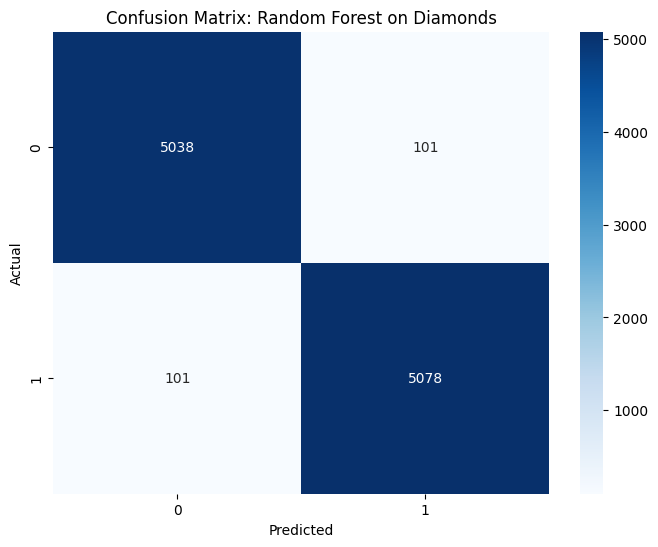

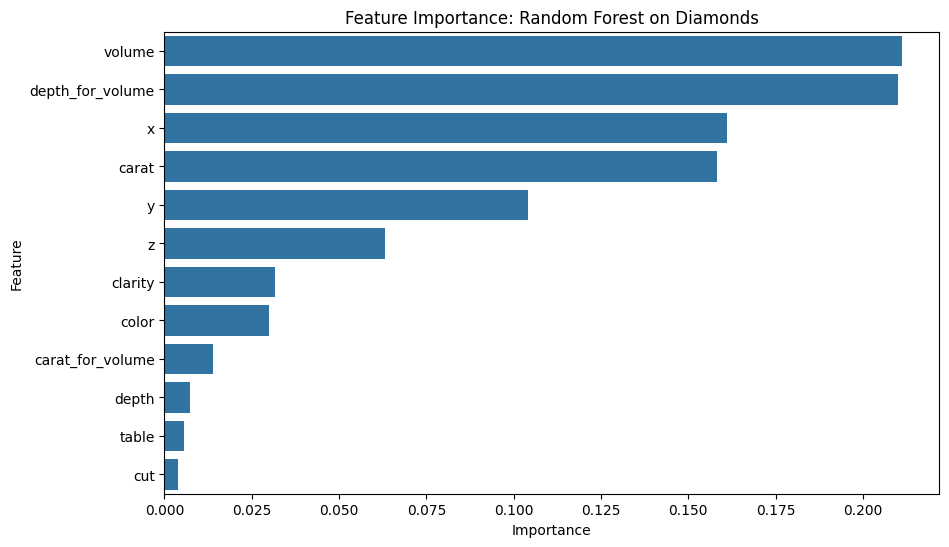

In [20]:
## Forest, alberi decisionali su diamonds ovvero df_zscore
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 1. Caricamento dati
# Per semplicità, usiamo il dataset breast_cancer di sklearn, ma in un caso reale useremmo df_zscore
X = df_zscore.drop(columns=['price'])
y = df_zscore['price']

# 2. Split dei dati
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

# 3. Inizializzazione e addestramento del modello
model = RandomForestClassifier(n_estimators=100, random_state=41)
model.fit(X_train, y_train)

# 4. Predizioni
predictions = model.predict(X_test)

# 5. Valutazione
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# --- GRAFICO 1: MATRICE DI CONFUSIONE ---
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix: Random Forest on Diamonds')
plt.show()

# --- GRAFICO 2: FEATURE IMPORTANCE ---
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance: Random Forest on Diamonds')
plt.show()


## `Decision Tree`

Confusion Matrix:
[[5000  139]
 [ 122 5057]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.97      0.97      5139
         1.0       0.97      0.98      0.97      5179

    accuracy                           0.97     10318
   macro avg       0.97      0.97      0.97     10318
weighted avg       0.97      0.97      0.97     10318



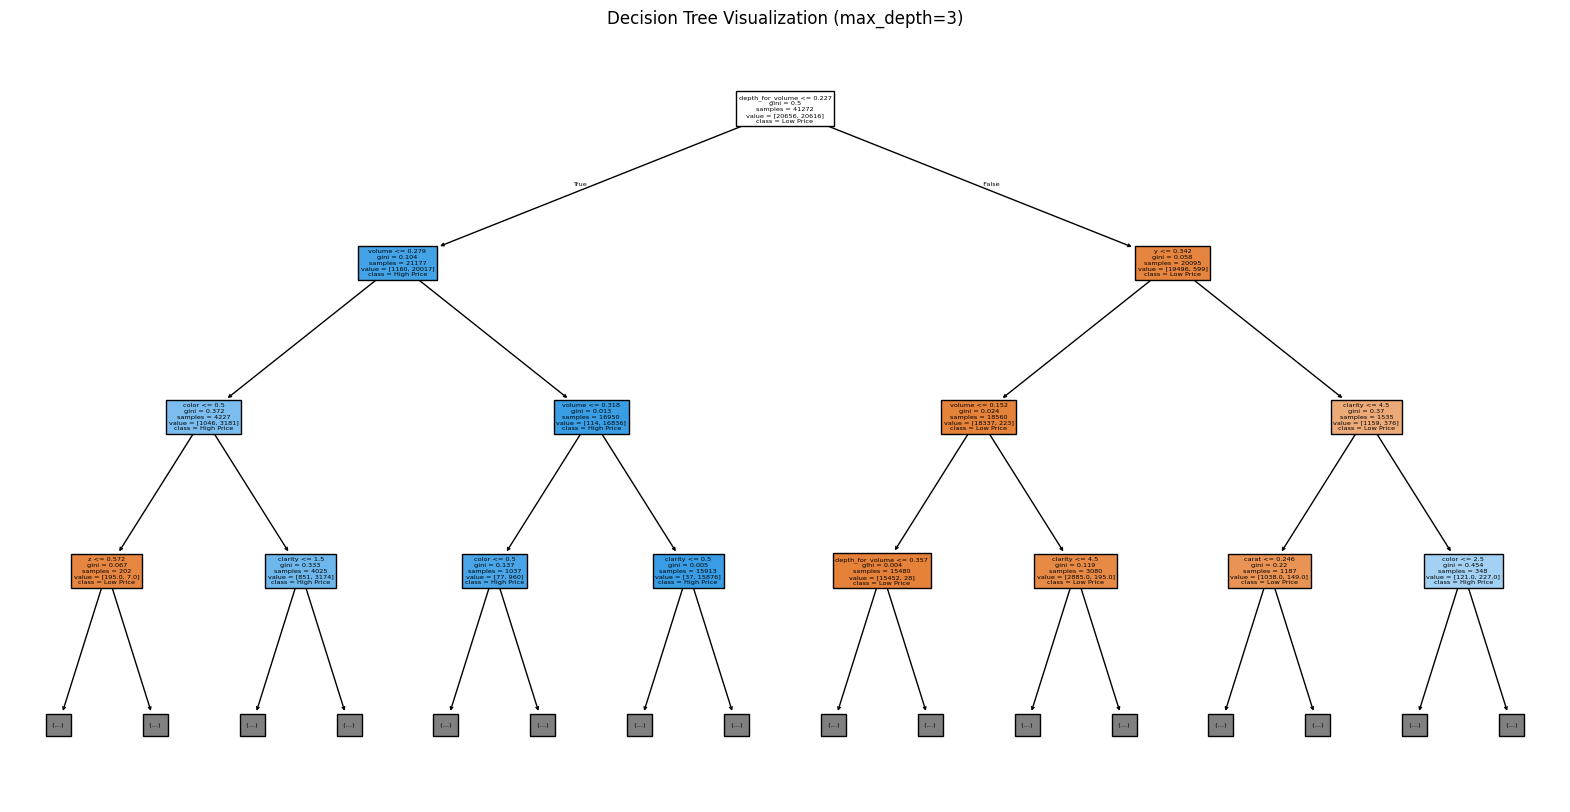

In [21]:
## Decision Tree su df_zscore
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Inizializzazione e addestramento del modello
dt_model = DecisionTreeClassifier(random_state=41)
dt_model.fit(X_train, y_train)

# Predizioni
dt_predictions = dt_model.predict(X_test)

# Valutazione
cm = confusion_matrix(y_test, dt_predictions)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))
'''
# --- SOTTO-GRAFICO 1: Confini di Decisione ---
plt.figure(figsize=(12, 6))
sns.scatterplot(x=X_test['carat'], y=X_test['price_for_carat'], hue=y_test, palette='Set1', edgecolor='k', alpha=0.7)
plt.title('Decision Boundaries: Decision Tree on Diamonds')
plt.xlabel('Carat')
plt.ylabel('Price for Carat')
plt.legend(title='Price Category')
plt.show() '''

# --- SOTTO-GRAFICO 2: Albero Decisionale ---
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=['Low Price', 'High Price'], filled=True, max_depth=3)
plt.title('Decision Tree Visualization (max_depth=3)')
plt.show()

## `XGBoos, correzione degli alberi decisionali da sinistra verso destra`

- se usiamo xgboos, questo gestisce da solo sia le variabili categoriche che i nulli. quindi quando usiamo xgboos dobbiamo solo fare la rimozione outliers, feature engineering, riduzione della dimensionalità

c:\Users\mcvis\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:39:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


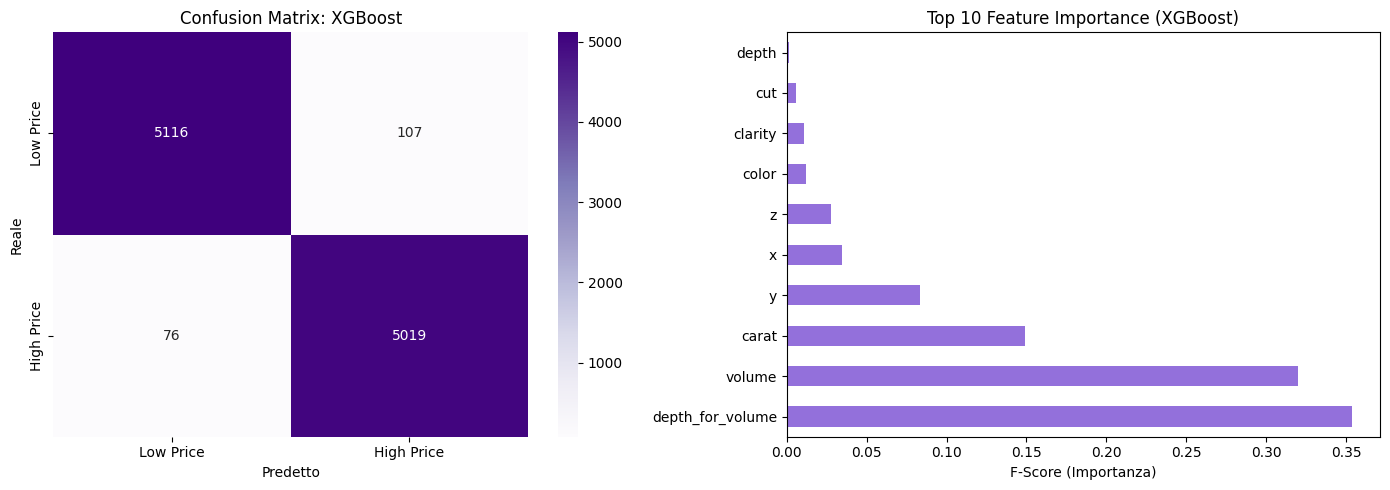

Accuratezza XGBoost: 98.23%

Report Tecnico:
              precision    recall  f1-score   support

   Low Price       0.99      0.98      0.98      5223
  High Price       0.98      0.99      0.98      5095

    accuracy                           0.98     10318
   macro avg       0.98      0.98      0.98     10318
weighted avg       0.98      0.98      0.98     10318



In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from xgboost import XGBClassifier

# Split Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Configurazione del modello XGBoost
# I parametri chiave:
# n_estimators: numero di alberi sequenziali
# learning_rate (eta): quanto pesano le correzioni di ogni nuovo albero (previene overfitting)
# max_depth: profondità di ogni albero
# gamma: parametro di regolarizzazione (minima riduzione della perdita per fare uno split)
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    gamma=0.1,
    use_label_encoder=False,
    eval_metric='logloss', # Evita i warning e specifica la funzione di costo
    random_state=42
)

# 3. Addestramento
xgb_model.fit(X_train, y_train)

# 4. Predizione
y_pred = xgb_model.predict(X_test)

# --- VISUALIZZAZIONE RISULTATI ---
plt.figure(figsize=(14, 5))

# Grafico 1: Matrice di Confusione
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Low Price', 'High Price'], 
            yticklabels=['Low Price', 'High Price'])
plt.title('Confusion Matrix: XGBoost')
plt.xlabel('Predetto')
plt.ylabel('Reale')

# Grafico 2: Feature Importance di XGBoost
plt.subplot(1, 2, 2)
# XGBoost ha un suo metodo per calcolare l'importanza delle feature
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='mediumpurple')
plt.title('Top 10 Feature Importance (XGBoost)')
plt.xlabel('F-Score (Importanza)')

plt.tight_layout()
plt.show()

# Metriche finali
print(f"Accuratezza XGBoost: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nReport Tecnico:")
print(classification_report(y_test, y_pred, target_names=['Low Price', 'High Price']))